In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [5]:
#STEP 1: LOAD THE DATASET
# =====================================================================
df = pd.read_csv('train.csv')

In [6]:
#STEP 2: DATA CLEANING (Handling Missing Values)
# =====================================================================
# Patch numerical columns with Median
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].median())

# Patch categorical columns with Mode
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

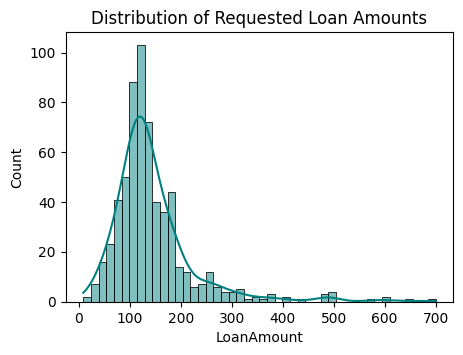

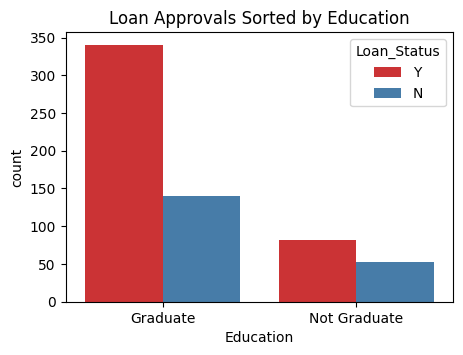

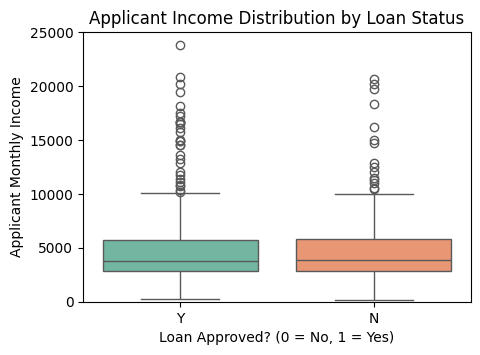

In [8]:
# STEP 3: EXPLORATORY DATA ANALYSIS (EDA)
# =====================================================================
# 1. Distribution of Loan Amounts (Histogram)
plt.figure(figsize=(5, 3.5))
sns.histplot(df['LoanAmount'], kde=True, color='teal')
plt.title('Distribution of Requested Loan Amounts')
plt.show()

# 2. Education Level vs Loan Approval Status (Countplot)
plt.figure(figsize=(5, 3.5))
sns.countplot(data=df, x='Education', hue='Loan_Status', palette='Set1')
plt.title('Loan Approvals Sorted by Education')
plt.show()

# Graph 3: Income Feature (Box Plot)
plt.figure(figsize=(5, 3.5))
sns.boxplot(data=df, x='Loan_Status', y='ApplicantIncome', hue='Loan_Status', palette='Set2', legend=False)
plt.title('Applicant Income Distribution by Loan Status')
plt.xlabel('Loan Approved? (0 = No, 1 = Yes)')
plt.ylabel('Applicant Monthly Income')
# Limiting y-axis slightly because extreme millionaire outliers compress the box shape
plt.ylim(0, 25000) 
plt.show()

In [9]:
# STEP 4: PREPROCESSING (Translating Text to Numbers)
# =====================================================================
df = df.drop(columns=['Loan_ID']) # Drop identification tag column

# One-Hot Encoding text categories into 0s and 1s
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Turn target variable into binary options: Y -> 1, N -> 0
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

# Split features (X) and target outputs (y)
X = df.drop(columns=['Loan_Status'])
y = df['Loan_Status']

# Split data into 80% Train and 20% Test segments
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Level the numeric playing field (Scaling)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
# STEP 5: TRAINING THE MODEL
# =====================================================================
model = LogisticRegression()
model.fit(X_train, y_train) # Training happens here

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Final Model Accuracy: 78.86%


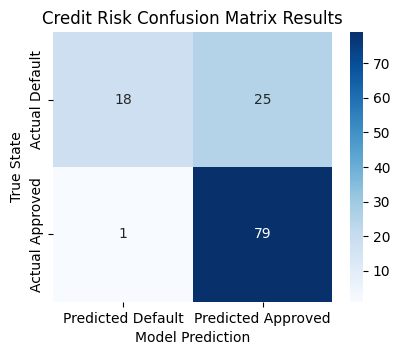

In [11]:
# STEP 6: EVALUATION (The Final Test)
# =====================================================================
y_pred = model.predict(X_test)

print(f"Final Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# Generate and display the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5, 3.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Default', 'Predicted Approved'], 
            yticklabels=['Actual Default', 'Actual Approved'])
plt.title('Credit Risk Confusion Matrix Results')
plt.ylabel('True State')
plt.xlabel('Model Prediction')
plt.show()

In [22]:
# =====================================================================
# TEST THE MODEL WITH A CUSTOM APPLICANT PROFILE
# =====================================================================

# 1. Define a brand new applicant's profile
# Change these values to test different scenarios!
custom_applicant = {
    'ApplicantIncome': 6000,      # Monthly Income ($)
    'CoapplicantIncome': 2000,    # Co-applicant Monthly Income ($)
    'LoanAmount': 150,            # Requested Loan Amount (in thousands: $150,000)
    'Loan_Amount_Term': 360,      # Term in days (360 days = 30-year loan)
    'Credit_History': 1.0,        # 1.0 = Good Credit History, 0.0 = Bad Credit History
    'Gender': 'Male',
    'Married': 'Yes',
    'Dependents': '2',
    'Education': 'Graduate',
    'Self_Employed': 'No',
    'Property_Area': 'Urban'
}

# 2. Convert this single profile into a Pandas DataFrame
input_df = pd.DataFrame([custom_applicant])

# 3. Align columns with our training data layout (One-Hot Encoding)
input_encoded = pd.get_dummies(input_df)
input_encoded = input_encoded.reindex(columns=X.columns, fill_value=0)

# 4. Scale the input values using our existing scaler tool
input_scaled = scaler.transform(input_encoded)

# 5. Let the model calculate the prediction!
prediction = model.predict(input_scaled)
probability = model.predict_proba(input_scaled)[0][1] # Probability of approval

# =====================================================================
# DISPLAY THE BANK'S DECISION
# =====================================================================
print("--- Bank Decision Engine Results ---")
print(f"Approval Confidence: {probability * 100:.2f}%")

if prediction[0] == 1:
    print("🎉 STATUS: LOAN APPROVED!")
else:
    print("❌ STATUS: LOAN DENIED (High Risk of Default)")

--- Bank Decision Engine Results ---
Approval Confidence: 86.49%
🎉 STATUS: LOAN APPROVED!
